In [1]:
import pickle
import pandas as pd
import numpy as np
import gc

## RF

In [2]:
filepath_base_rf = "model/debit/base_rf_ros_31_feats_20250702.pkl"
with open(filepath_base_rf, "rb") as f:
    base_rf = pickle.load(f)

## Data

In [3]:
df_final = pd.read_parquet("data/ready_to_train/df_debit_final_25_feats_20250702.parquet")

In [4]:
# setup pipeline
from src.model_pipeline import ModelPipeline

pipeline_rf = ModelPipeline(model_type="random_forest", random_state=42)

split_date = '2025-05-01'
df_splits = pipeline_rf.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


In [5]:
# prepare OOS data
target_col = "Confirmed"
X, y = pipeline_rf.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'HighRiskCustomer': ['0', 'N', '__missing__']
  Fitted categories for column 'POSMode': ['0', '1', '2', '5', '7', '9', '__missing__']
CategoryManager fitting complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['HighRiskCustomer', 'POSMode'], dtype='object')...
Identified numerical columns for imputation: ['SumAmtL30D', 'TxnCountL30D', 'CountTrxTrf', 'TotalTrxAmount10Mi', 'TotalTrxAmountL5min', 'TotalTrxAmount15Mi', 'CntUniqueCardNoByMCCL30D', 'TotalTrxAmountL1D', 'TransactionAmount', 'CustomerAge', 'RatioTrxAmountL1DL15min', 'RatioTrxAmountL1DL10min', 'RatioTrxAmountL1DL5min', 'MaxAmtL30D', 'AvgAmtL30D', 'RatioCntUniqueCardNoByMCCL30DL15min', 'RatioTxnCountL30DL15min', 'AvgTrnxHourL30d', 'TxnTimeDifference', 

In [6]:
X_oos, y_oos = pipeline_rf.prepare_data(
    df=df_splits["df_test"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['HighRiskCustomer', 'POSMode'], dtype='object')...
Identified numerical columns for imputation: ['SumAmtL30D', 'TxnCountL30D', 'CountTrxTrf', 'TotalTrxAmount10Mi', 'TotalTrxAmountL5min', 'TotalTrxAmount15Mi', 'CntUniqueCardNoByMCCL30D', 'TotalTrxAmountL1D', 'TransactionAmount', 'CustomerAge', 'RatioTrxAmountL1DL15min', 'RatioTrxAmountL1DL10min', 'RatioTrxAmountL1DL5min', 'MaxAmtL30D', 'AvgAmtL30D', 'RatioCntUniqueCardNoByMCCL30DL15min', 'RatioTxnCountL30DL15min', 'AvgTrnxHourL30d', 'TxnTimeDifference', 'TimeFirstTxnToCurrentMCC', 'AvgTimeFirstTxnToCurrentMCCL30D', 'AvgTrnxHourL15min', 'CntUniqueCardNoByMCCL15min']
Identified categorical columns (encoded): []
Transforming data using NumericalImputer...
  Imputed column 'SumA

# Binning Proba Analysis

In [7]:
from src.utils import plot_confusion_matrix, generate_pred_df, compute_bin_aggregates

In [9]:
df_pred = generate_pred_df(
    X=X_oos,
    y=y_oos,
    clf=base_rf,
    amount_col='TransactionAmount',
    bin_on='pbad',
    increment_bin_rate=0.025,
    bins=None
)

In [10]:
df_agg = compute_bin_aggregates(df_pred)

C:\Users\Administrator\BDI-predator\ml-fraud\src\utils.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = pred_df.groupby("bin").agg(agg_cols)


In [11]:
df_agg.to_csv("data/result/debit_rf_bin_proba_analysis_20250702.csv")

In [12]:
y_oos_prob = base_rf.predict_proba(X_oos)[:, 1]
df_pred = X_oos.join(y_oos)
df_pred = df_pred[['Confirmed']]

In [13]:
df_pred['P_Bad'] = y_oos_prob
df_pred['Confirmed'] = df_pred['Confirmed'].astype(int)

In [14]:
df_pred.to_csv("data/result/DEBIT_df_pred_oos_rf_20250703.csv")

# Importance Feat

In [17]:
df_importance = pd.DataFrame(
    {"feature": X.columns, "importance": base_rf.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

In [18]:
df_importance.to_csv("data/result/debit_rf_importance_20250624.csv", index=False)

# FP Reduction

In [22]:
from src.utils import plot_confusion_matrix

In [23]:
y_oos_proba = base_rf.predict_proba(X_oos)[:, 1]

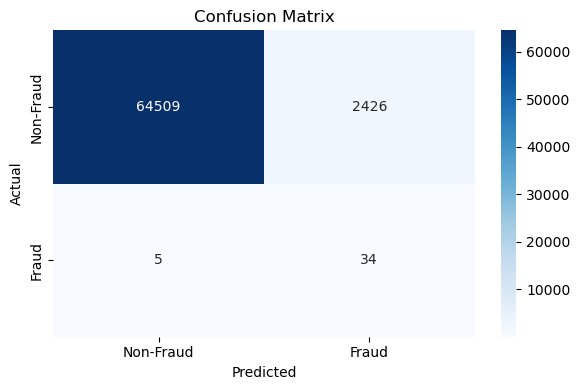

Recall/True Positive Rate: The model got 87.18% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 1.38% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 3.62% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [24]:
threshold_oos = 0.3
plot_confusion_matrix(y_oos, y_oos_proba, threshold_oos)